In [1]:
import sys
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
seed = 5  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
#To get my GPU device - GTX 4070 :)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


In [3]:
from ASV_utils.data_loading import *



models_folder = "ECAPA_TDNN/inference_models/"

data_path_male = "Data/pmf_both/not_normalize/male/"

data_path_female = "Data/pmf_both/not_normalize/female/"

embedded_groups_1_1_male,embedded_groups_1_2_male,embedded_groups_1_3_male,chosen_labels_1_1_is_spoofed_male,chosen_labels_2_1_is_spoofed_male,chosen_labels_3_1_is_spoofed_male,chosen_labels_numeric_1_1_male,chosen_labels_numeric_2_1_male,chosen_labels_numeric_3_1_male,chosen_labels_1_1_attack_logical_male,chosen_labels_2_1_attack_logical_male,chosen_labels_3_1_attack_logical_male,chosen_labels_1_1_name_male,chosen_labels_2_1_name_male,chosen_labels_3_1_name_male,chosen_labels_1_1_speaker_id_male,chosen_labels_2_1_speaker_id_male,chosen_labels_3_1_speaker_id_male,male_chosen_labels_1_1_sex_male,male_chosen_labels_2_1_sex_male,male_chosen_labels_3_1_sex_male  = load_data_male(data_path_male)

embedded_groups_1_1_female,embedded_groups_1_2_female,embedded_groups_1_3_female,chosen_labels_1_1_is_spoofed_female,chosen_labels_2_1_is_spoofed_female,chosen_labels_3_1_is_spoofed_female,chosen_labels_numeric_1_1_female,chosen_labels_numeric_2_1_female,chosen_labels_numeric_3_1_female,chosen_labels_1_1_attack_logical_female,chosen_labels_2_1_attack_logical_female,chosen_labels_3_1_attack_logical_female,chosen_labels_1_1_name_female,chosen_labels_2_1_name_female,chosen_labels_3_1_name_female,chosen_labels_1_1_speaker_id_female,chosen_labels_2_1_speaker_id_female,chosen_labels_3_1_speaker_id_female,female_chosen_labels_1_1_sex_female,female_chosen_labels_2_1_sex_female,female_chosen_labels_3_1_sex_female   = load_data_female(data_path_female)

In [4]:
## load Embedded Groups
# Group 1 - Train Set
# Group 2 - Dev Set - validation set
# Grup 3 - Eval Set - test set
embedded_groups_1_1 = np.vstack((embedded_groups_1_1_male,embedded_groups_1_1_female));
embedded_groups_1_2 = np.vstack((embedded_groups_1_2_male,embedded_groups_1_2_female));
embedded_groups_1_3 = np.vstack((embedded_groups_1_3_male,embedded_groups_1_3_female));

chosen_labels_1_1_is_spoofed = pd.concat([chosen_labels_1_1_is_spoofed_male,chosen_labels_1_1_is_spoofed_female]);
chosen_labels_2_1_is_spoofed = pd.concat([chosen_labels_2_1_is_spoofed_male,chosen_labels_2_1_is_spoofed_female]);
chosen_labels_3_1_is_spoofed = pd.concat([chosen_labels_3_1_is_spoofed_male,chosen_labels_3_1_is_spoofed_female]);
chosen_labels_1_1_is_spoofed.reset_index(drop=True,inplace=True)
chosen_labels_2_1_is_spoofed.reset_index(drop=True,inplace=True)
chosen_labels_3_1_is_spoofed.reset_index(drop=True,inplace=True)
 
chosen_labels_numeric_1_1 = pd.concat([chosen_labels_numeric_1_1_male,chosen_labels_numeric_1_1_female]);
chosen_labels_numeric_2_1 = pd.concat([chosen_labels_numeric_2_1_male,chosen_labels_numeric_2_1_female]);
chosen_labels_numeric_3_1 = pd.concat([chosen_labels_numeric_3_1_male,chosen_labels_numeric_3_1_female]);
chosen_labels_numeric_1_1.reset_index(drop=True,inplace=True)
chosen_labels_numeric_2_1.reset_index(drop=True,inplace=True)
chosen_labels_numeric_3_1.reset_index(drop=True,inplace=True)

chosen_labels_1_1_attack_logical = pd.concat([chosen_labels_1_1_attack_logical_male,chosen_labels_1_1_attack_logical_female]);
chosen_labels_2_1_attack_logical = pd.concat([chosen_labels_2_1_attack_logical_male,chosen_labels_2_1_attack_logical_female]);
chosen_labels_3_1_attack_logical = pd.concat([chosen_labels_3_1_attack_logical_male,chosen_labels_3_1_attack_logical_female]);
chosen_labels_1_1_attack_logical.reset_index(drop=True,inplace=True)
chosen_labels_2_1_attack_logical.reset_index(drop=True,inplace=True)
chosen_labels_3_1_attack_logical.reset_index(drop=True,inplace=True)

chosen_labels_1_1_name = pd.concat([chosen_labels_1_1_name_male,chosen_labels_1_1_name_female]);
chosen_labels_2_1_name = pd.concat([chosen_labels_2_1_name_male,chosen_labels_2_1_name_female]);
chosen_labels_3_1_name = pd.concat([chosen_labels_3_1_name_male,chosen_labels_3_1_name_female]);
chosen_labels_1_1_name.reset_index(drop=True,inplace=True)
chosen_labels_2_1_name.reset_index(drop=True,inplace=True)
chosen_labels_3_1_name.reset_index(drop=True,inplace=True)

chosen_labels_1_1_speaker_id = pd.concat([chosen_labels_1_1_speaker_id_male,chosen_labels_1_1_speaker_id_female]);
chosen_labels_2_1_speaker_id = pd.concat([chosen_labels_2_1_speaker_id_male,chosen_labels_2_1_speaker_id_female]);
chosen_labels_3_1_speaker_id = pd.concat([chosen_labels_3_1_speaker_id_male,chosen_labels_3_1_speaker_id_female]);
chosen_labels_1_1_speaker_id.reset_index(drop=True,inplace=True)
chosen_labels_2_1_speaker_id.reset_index(drop=True,inplace=True)
chosen_labels_3_1_speaker_id.reset_index(drop=True,inplace=True)

chosen_labels_1_1_sex = pd.concat([male_chosen_labels_1_1_sex_male,female_chosen_labels_1_1_sex_female]);
chosen_labels_2_1_sex = pd.concat([male_chosen_labels_2_1_sex_male,female_chosen_labels_2_1_sex_female]);
chosen_labels_3_1_sex = pd.concat([male_chosen_labels_3_1_sex_male,female_chosen_labels_3_1_sex_female]);
chosen_labels_1_1_sex.reset_index(drop=True,inplace=True)
chosen_labels_2_1_sex.reset_index(drop=True,inplace=True)
chosen_labels_3_1_sex.reset_index(drop=True,inplace=True)

## Preprocessing channels

Here, I will perform preprocessing and rearrange the channel order before feeding it into the Deep Neural Network (DNN).

In [5]:
#order by this example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Hellinger-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Intersection-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Jensen-Shannon-[d_(p,p_s)-d(p,p_h)

# get the real channel by the order of the features

import utils.my_functions as my_functions
columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)
embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

In [6]:
# order by metric type and then by channel number and then by gammatone and gammatone_inv, example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
import re


your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract filter type, channel number, and distance metric
    match = re.search(r'filter-(gammatone|gammtone_inv)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        filter_type = match.group(1)  # 'gammatone' or 'gammtone_inv'
        channel = int(match.group(2))
        distance_metric = match.group(3)
        
        # Prioritize 'gammatone' before 'gammtone_inv'
        filter_priority = 0 if filter_type == 'gammatone' else 1

        # Sort by filter type, then by distance metric, and finally by channel
        return (filter_priority, distance_metrics.index(distance_metric), channel)

    else:
        # If the regex doesn't match, push the item to the end
        return (999, 999, 999)

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]

In [7]:
sorted_list

['filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-3-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-4-distance-Correlation-[d_(p,p_s)

In [8]:
train_dataset = dataset(data = embedded_groups_1_1 , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id,sex = chosen_labels_1_1_sex, data_transform = None , labels_transform = None);

validation_dataset = dataset(data = embedded_groups_1_2 , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,data_transform = None , labels_transform = None);


test_dataset = dataset(data = embedded_groups_1_3 , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = chosen_labels_3_1_sex ,data_transform = None , labels_transform = None);

In [9]:
# normalize the train, validation and test datasets
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(train_dataset.data)
mean_features = scaler.mean_
std_features = scaler.scale_
train_dataset.data = scaler.transform(train_dataset.data)
validation_dataset.data = scaler.transform(validation_dataset.data)
test_dataset.data = scaler.transform(test_dataset.data)

In [10]:
# balanced the data with SVM SMOTE
import imblearn.over_sampling as over_sampling

sm = over_sampling.SVMSMOTE(sampling_strategy='minority', random_state=seed,k_neighbors=5)
train_dataset.data , train_dataset.is_spoofed  = sm.fit_resample(X = train_dataset.data , y = train_dataset.is_spoofed) # just on the train set

In [11]:
#check if the data now is balanced
print(f"|| train dataset length - {len(train_dataset)} ||");
print(f"|| train dataset - len_is_spoofed ? \nlength - \n{train_dataset.len_is_spoofed()} ||");
print(f"|| validation dataset length - {len(validation_dataset)} ||");
print(f"|| validation dataset - len_is_spoofed ? \nlength - \n{validation_dataset.len_is_spoofed()} ||");
print(f"|| test dataset length - {len(test_dataset)} ||");
print(f"|| test dataset - len_is_spoofed ? \nlength - \n{test_dataset.len_is_spoofed()} ||");

|| train dataset length - 45600 ||
|| train dataset - len_is_spoofed ? 
length - 
0    22800
1    22800
Name: count, dtype: int64 ||
|| validation dataset length - 24844 ||
|| validation dataset - len_is_spoofed ? 
length - 
1    22296
0     2548
Name: count, dtype: int64 ||
|| test dataset length - 71237 ||
|| test dataset - len_is_spoofed ? 
length - 
1    63882
0     7355
Name: count, dtype: int64 ||


In [12]:

#chat - gpt 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 
# Ensure data is a Pandas DataFrame
train_dataset.data = pd.DataFrame(train_dataset.data)

# Ensure columns are sorted
train_dataset.data.columns = sorted_list

# Compute the correlation matrix

set_data = train_dataset

# def compute_avg_over_metrices_type(set_data):
#         # Define the number of rows and columns for submatrix
#         num_cols = 10
#         num_rows = 10


#         corr_matrices = []
#         mean_matrices = []
#         for i in range(0, set_data.data.shape[1], 10):
#                 sub_data = set_data.data.iloc[:,i:i+10]
#                 print(train_dataset.data.columns[i:i+10])
#                 corr_matrices.append(sub_data.corr())
#                 mean_matrices.append(np.mean(sub_data))


#         # Convert the list to a 3D NumPy array
#         corr_matrices = np.array(corr_matrices)
#         print("corr_matrices shape:",corr_matrices.shape)

#         # Calculate mean and variance using NumPy
#         mean_corr_matrix = np.mean(corr_matrices, axis=0)
#         variance_corr_matrix = np.std(corr_matrices, axis=0)



#         # mean_titles = [f"Channel {idx+1}: Mean and Std across 8 Similarity Measures" for idx in range(10)]
#         # std_titles = [f"Channel {idx+1}: Mean and Std across 8 Similarity Measures" for idx in range(10)]
#         mean_titles = [f"Channel {idx+1} - Mean (Std) Similarity Measures" for idx in range(10)]
#         std_titles = [f"Channel {idx+1} - Mean (Std) Similarity Measures" for idx in range(10)]




#         # Convert to DataFrames for better visualization
#         mean_corr_df = pd.DataFrame(mean_corr_matrix,  index=mean_titles,columns=mean_titles)
#         variance_corr_df = pd.DataFrame(variance_corr_matrix, index=std_titles, columns=std_titles)

#         # Ensure both matrices have the same shape and indices
#         assert mean_corr_df.shape == variance_corr_df.shape, "Matrices must have the same shape."
#         assert (mean_corr_df.index == variance_corr_df.index).all(), "Row indices must match."
#         assert (mean_corr_df.columns == variance_corr_df.columns).all(), "Column indices must match."

#         # Create a combined annotation matrix with mean and variance values
#         annotations = mean_corr_df.round(2).astype(str) + " (" + variance_corr_df.round(2).astype(str) + ")"

#         plt.figure(figsize=(30, 20))
#         sns.heatmap(mean_corr_df, fmt="", cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"color": "black", "size": 22})#annot=annotations)  # Set annotation text color to black)

#         plt.title("Training Set - Mean (Std) Across 10 Channels for Each Similarity Measure", fontsize=30)

#         plt.xticks(rotation=45, ha='right', fontsize=24)
#         plt.yticks(rotation=0, fontsize=24)
#         plt.tight_layout()
#         plt.show()

#         # Create a mask to exclude the main diagonal
#         mask = ~np.eye(10, dtype=bool)  # Inverts the mask to exclude the diagonal

#         # Apply the mask and calculate mean and std for each matrix
#         mean_scalars = np.array([m[mask].mean() for m in corr_matrices])
#         std_scalars = np.array([m[mask].std() for m in corr_matrices])
#         print("mean 16 matrixes by similarity measures:",mean_scalars)
#         print("std 16 matrixes by similarity measures:",std_scalars)


#        # mean_of_means = np.mean(mean_scalars)
#        # std_of_means = np.std(mean_scalars)
#         mask = ~np.eye(10, dtype=bool)
#         mean_of_means = np.mean(mean_corr_df[mask])
#         std_of_means =  np.std(mean_corr_df[mask])
#         print("mean of means:",mean_of_means)
#         print("std of means:",std_of_means)

#         return mean_corr_df,variance_corr_df,mean_of_means, std_of_means

#mean_corr_df,variance_corr_df,mean_of_means, std_of_means = compute_avg_over_metrices_type(set_data)

Index(['filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]'],
      dtype='object')
Index(['filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-3-dis

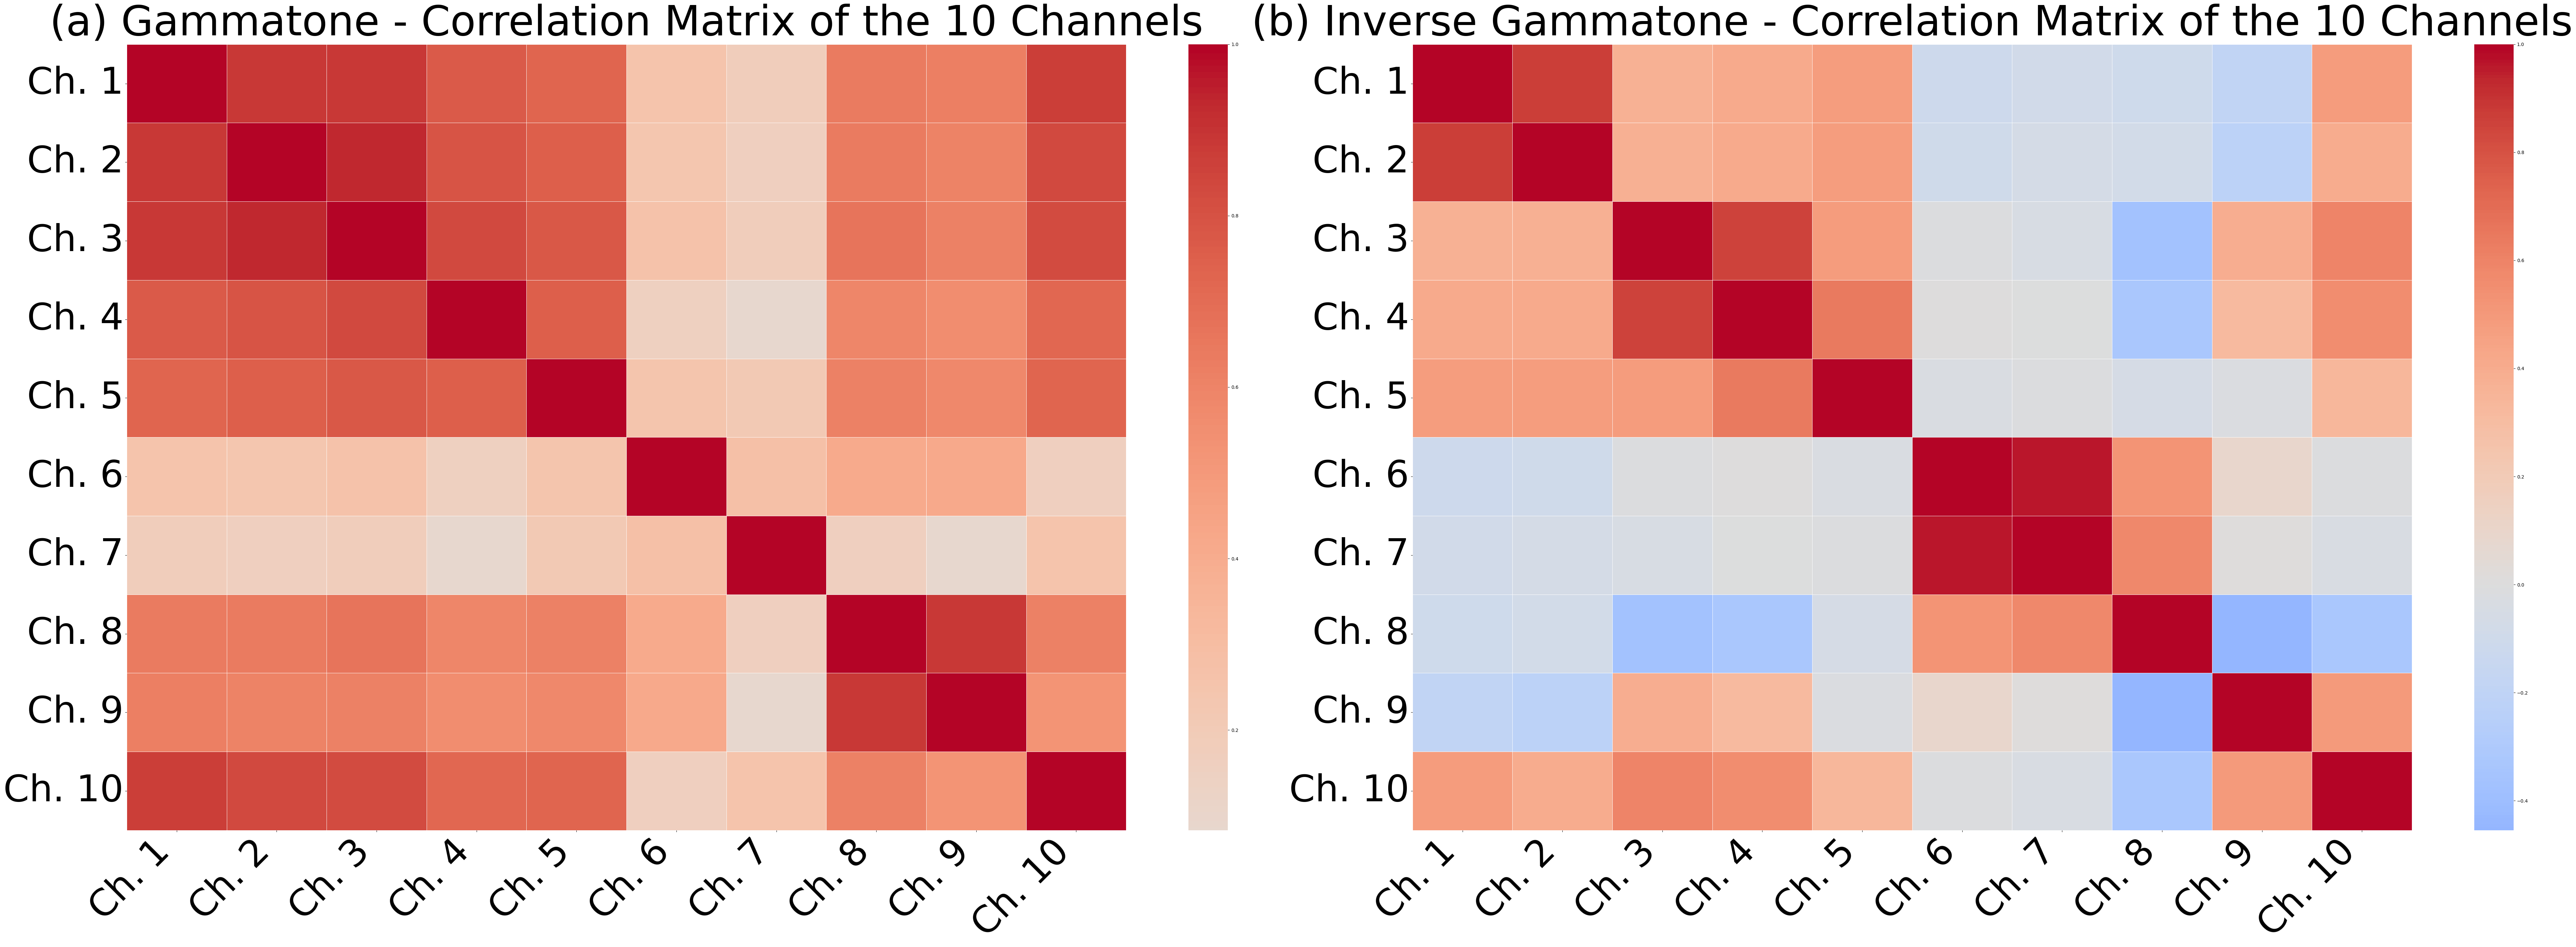

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Your data preparation (assumed already done)
train_dataset.data = pd.DataFrame(train_dataset.data)
train_dataset.data.columns = sorted_list
set_data = train_dataset

def compute_avg_over_metrices_type(set_data):
    num_cols = 10
    num_rows = 10

    corr_matrices = []
    mean_matrices = []

    for i in range(0, set_data.data.shape[1], 10):
        sub_data = set_data.data.iloc[:, i:i+10]
        print(set_data.data.columns[i:i+10])
        corr_matrices.append(sub_data.corr())
        mean_matrices.append(np.mean(sub_data))

    corr_matrices = np.array(corr_matrices)
    print("corr_matrices shape:", corr_matrices.shape)  # should be (16, 10, 10)

    ### Split into gammatone and inverse-gammatone
    gammatone_corr_matrices = corr_matrices[:8]
    inv_gammatone_corr_matrices = corr_matrices[8:]

    results = {}

    # Prepare the main figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(80, 30))  # Make it wide enough for two big plots

    for idx, (name, matrices) in enumerate(zip(["Gammatone", "Inverse Gammatone"], [gammatone_corr_matrices, inv_gammatone_corr_matrices])):
        mean_corr_matrix = np.mean(matrices, axis=0)
        variance_corr_matrix = np.std(matrices, axis=0)

        mean_titles = [f"Ch. {idx+1}" for idx in range(10)]

        mean_corr_df = pd.DataFrame(mean_corr_matrix, index=mean_titles, columns=mean_titles)
        variance_corr_df = pd.DataFrame(variance_corr_matrix, index=mean_titles, columns=mean_titles)

        ax = axes[idx]
        sns.heatmap(mean_corr_df, ax=ax, fmt="", cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"color": "black", "size": 22})
        
        if name == "Gammatone":
            ax.set_title("(a) Gammatone - Correlation Matrix of the 10 Channels", fontsize=90, pad=20)
        else:
            ax.set_title("(b) Inverse Gammatone - Correlation Matrix of the 10 Channels", fontsize=90, pad=20)

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=80)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=80)

        mask = ~np.eye(10, dtype=bool)

        mean_of_means = np.mean(mean_corr_matrix[mask])
        std_of_means = np.std(mean_corr_matrix[mask])

        print(f"{name} - mean of means:", mean_of_means)
        print(f"{name} - std of means:", std_of_means)

        results[name] = {
            "mean_corr_df": mean_corr_df,
            "variance_corr_df": variance_corr_df,
            "mean_of_means": mean_of_means,
            "std_of_means": std_of_means
        }

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Tight layout but reserve a bit space
    plt.show()

    return results

# Call the function
results = compute_avg_over_metrices_type(set_data)

# Access results separately
gammatone_results = results["Gammatone"]
inv_gammatone_results = results["Inverse Gammatone"]




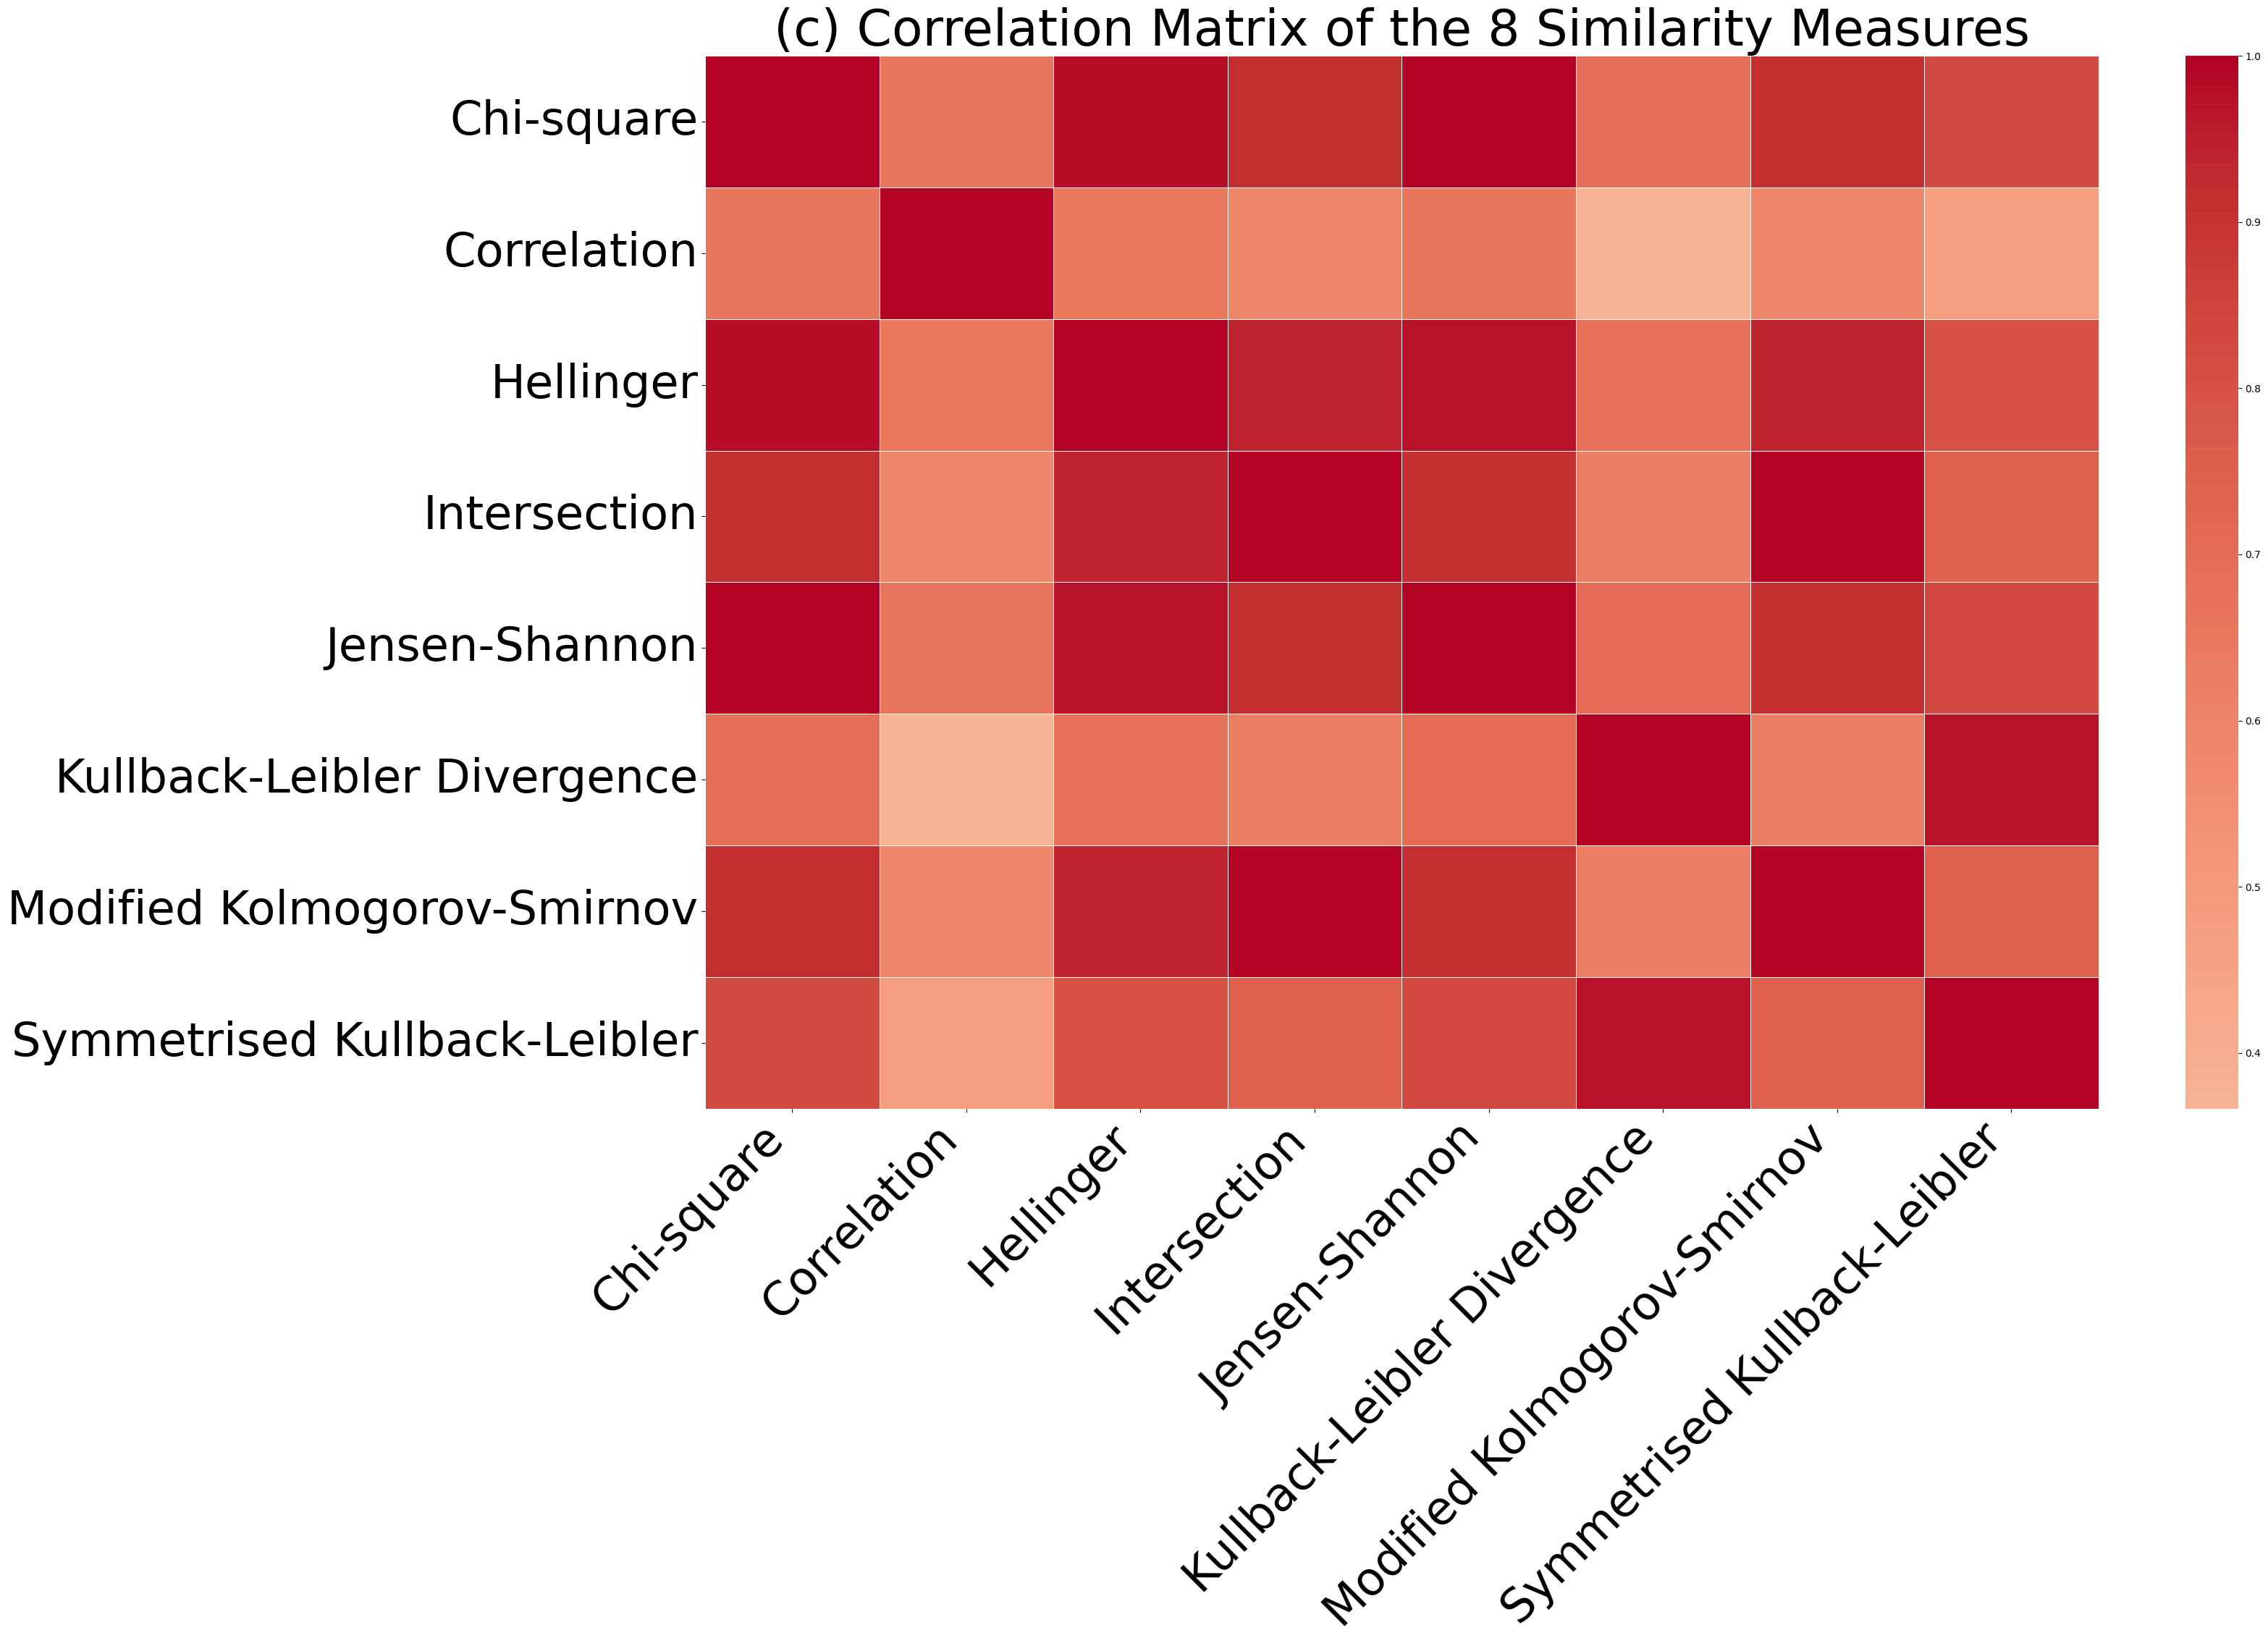

mean of means: 0.7756425955638822
std of means: 0.16845886007267363


In [41]:
#chat - gpt 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_over_channels(set_data):

    # Initialize variables
    total_channels = 10
    matrices = []
    all_selected_features = None


    # Ensure columns are sorted
    set1 = set_data.data
    set1 = set1[sorted_list]

    # Prefixes to iterate over
    prefixes = ['filter-gammatone-channel-', 'filter-gammtone_inv-channel-']

    # Initialize lists to store results
    matrices = []
    all_selected_features = None

    for prefix in prefixes:
        for channel in range(1, total_channels + 1):
            channel_prefix = f'{prefix}{channel}-'
            
            # Select features for the current channel
            selected_features = [feat for feat in set1.columns if feat.startswith(channel_prefix)]
            
            if not selected_features:
                continue
            
            # Extract the sub-correlation matrix
            sub_matrix = set1[selected_features]
            matrices.append(sub_matrix.corr().to_numpy())
            
            # Save feature names for labeling (assuming consistency across channels)
            if all_selected_features is None:
                all_selected_features = selected_features

    # Convert the list to a 3D NumPy array for efficient computation
    matrices = np.array(matrices)


    # Calculate mean and variance using numpy functions
    mean_corr_matrix = np.mean(matrices, axis=0)
    variance_corr_matrix = np.std(matrices, axis=0)

    type_similarity = ['Chi-square', 'Correlation', 'Hellinger', 'Intersection', 'Jensen-Shannon', 'Kullback-Leibler Divergence', 'Modified Kolmogorov-Smirnov', 'Symmetrised Kullback-Leibler']
    mean_titles = [f"Mean over all the Channels for {type_similarity[idx]} similarity measures" for idx in range(8)]
    std_titles = [f"Std over all the Channels for {type_similarity[idx]} similarity measures"  for idx in range(8)]

    # Convert to DataFrames for better visualization
    mean_corr_df = pd.DataFrame(mean_corr_matrix,  index=mean_titles,columns=mean_titles)
    variance_corr_df = pd.DataFrame(variance_corr_matrix, index=std_titles, columns=std_titles)




    type_similarity = [
        'Chi-square', 'Correlation', 'Hellinger', 'Intersection',
        'Jensen-Shannon', 'Kullback-Leibler Divergence',
        'Modified Kolmogorov-Smirnov', 'Symmetrised Kullback-Leibler'
    ]


    combined_titles = [
        f"{sim}"
        #: Across {total_channels} Channels" 
        for sim in type_similarity
    ]



    # Convert to DataFrames for better visualization
    mean_corr_df = pd.DataFrame(mean_corr_matrix,  index=combined_titles,columns=combined_titles)
    variance_corr_df = pd.DataFrame(variance_corr_matrix, index=combined_titles, columns=combined_titles)


    # Ensure both matrices have the same shape and indices
    assert mean_corr_df.shape == variance_corr_df.shape, "Matrices must have the same shape."
    assert (mean_corr_df.index == variance_corr_df.index).all(), "Row indices must match."
    assert (mean_corr_df.columns == variance_corr_df.columns).all(), "Column indices must match."

    # Create a combined annotation matrix with mean and variance values
    #annotations = mean_corr_df.round(2).astype(str) + " (" + variance_corr_df.round(2).astype(str) + ")"

    plt.figure(figsize=(34, 24))
    sns.heatmap(mean_corr_df, fmt="", cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"color": "black","size": 22})#, annot=annotations)  # Set annotation text color to black)
    plt.title("(c) Correlation Matrix of the 8 Similarity Measures", fontsize=50)
    plt.xticks(rotation=45, ha='right', fontsize=46)
    plt.yticks(rotation=0, fontsize=46)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.show()




    # Create a mask to exclude the main diagonal
    mask = ~np.eye(8, dtype=bool)  # Inverts the mask to exclude the diagonal

    # # Apply the mask and calculate mean and std for each matrix
    # mean_scalars = np.array([m[mask].mean() for m in matrices])
    # std_scalars = np.array([m[mask].std() for m in matrices])
    # print("mean 20 matrixes by channels:",mean_scalars)
    # print("std 20 matrixes by channels:",std_scalars)


    # mean_of_means = np.mean(mean_scalars)
    # std_of_means = np.std(mean_scalars)
    mean_of_means = np.mean(mean_corr_matrix[mask])
    std_of_means = np.std((mean_corr_matrix[mask]))
    print("mean of means:",mean_of_means)
    print("std of means:",std_of_means)
    
    
set_data = train_dataset

compute_over_channels(set_data)


In [15]:
sorted_list

['filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-3-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-4-distance-Correlation-[d_(p,p_s)

Gammatone features: ['filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]']
Inverse Gammatone features: ['filter-gammtone_inv-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammtone_inv-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammtone_inv-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]', 'filter-gammtone_

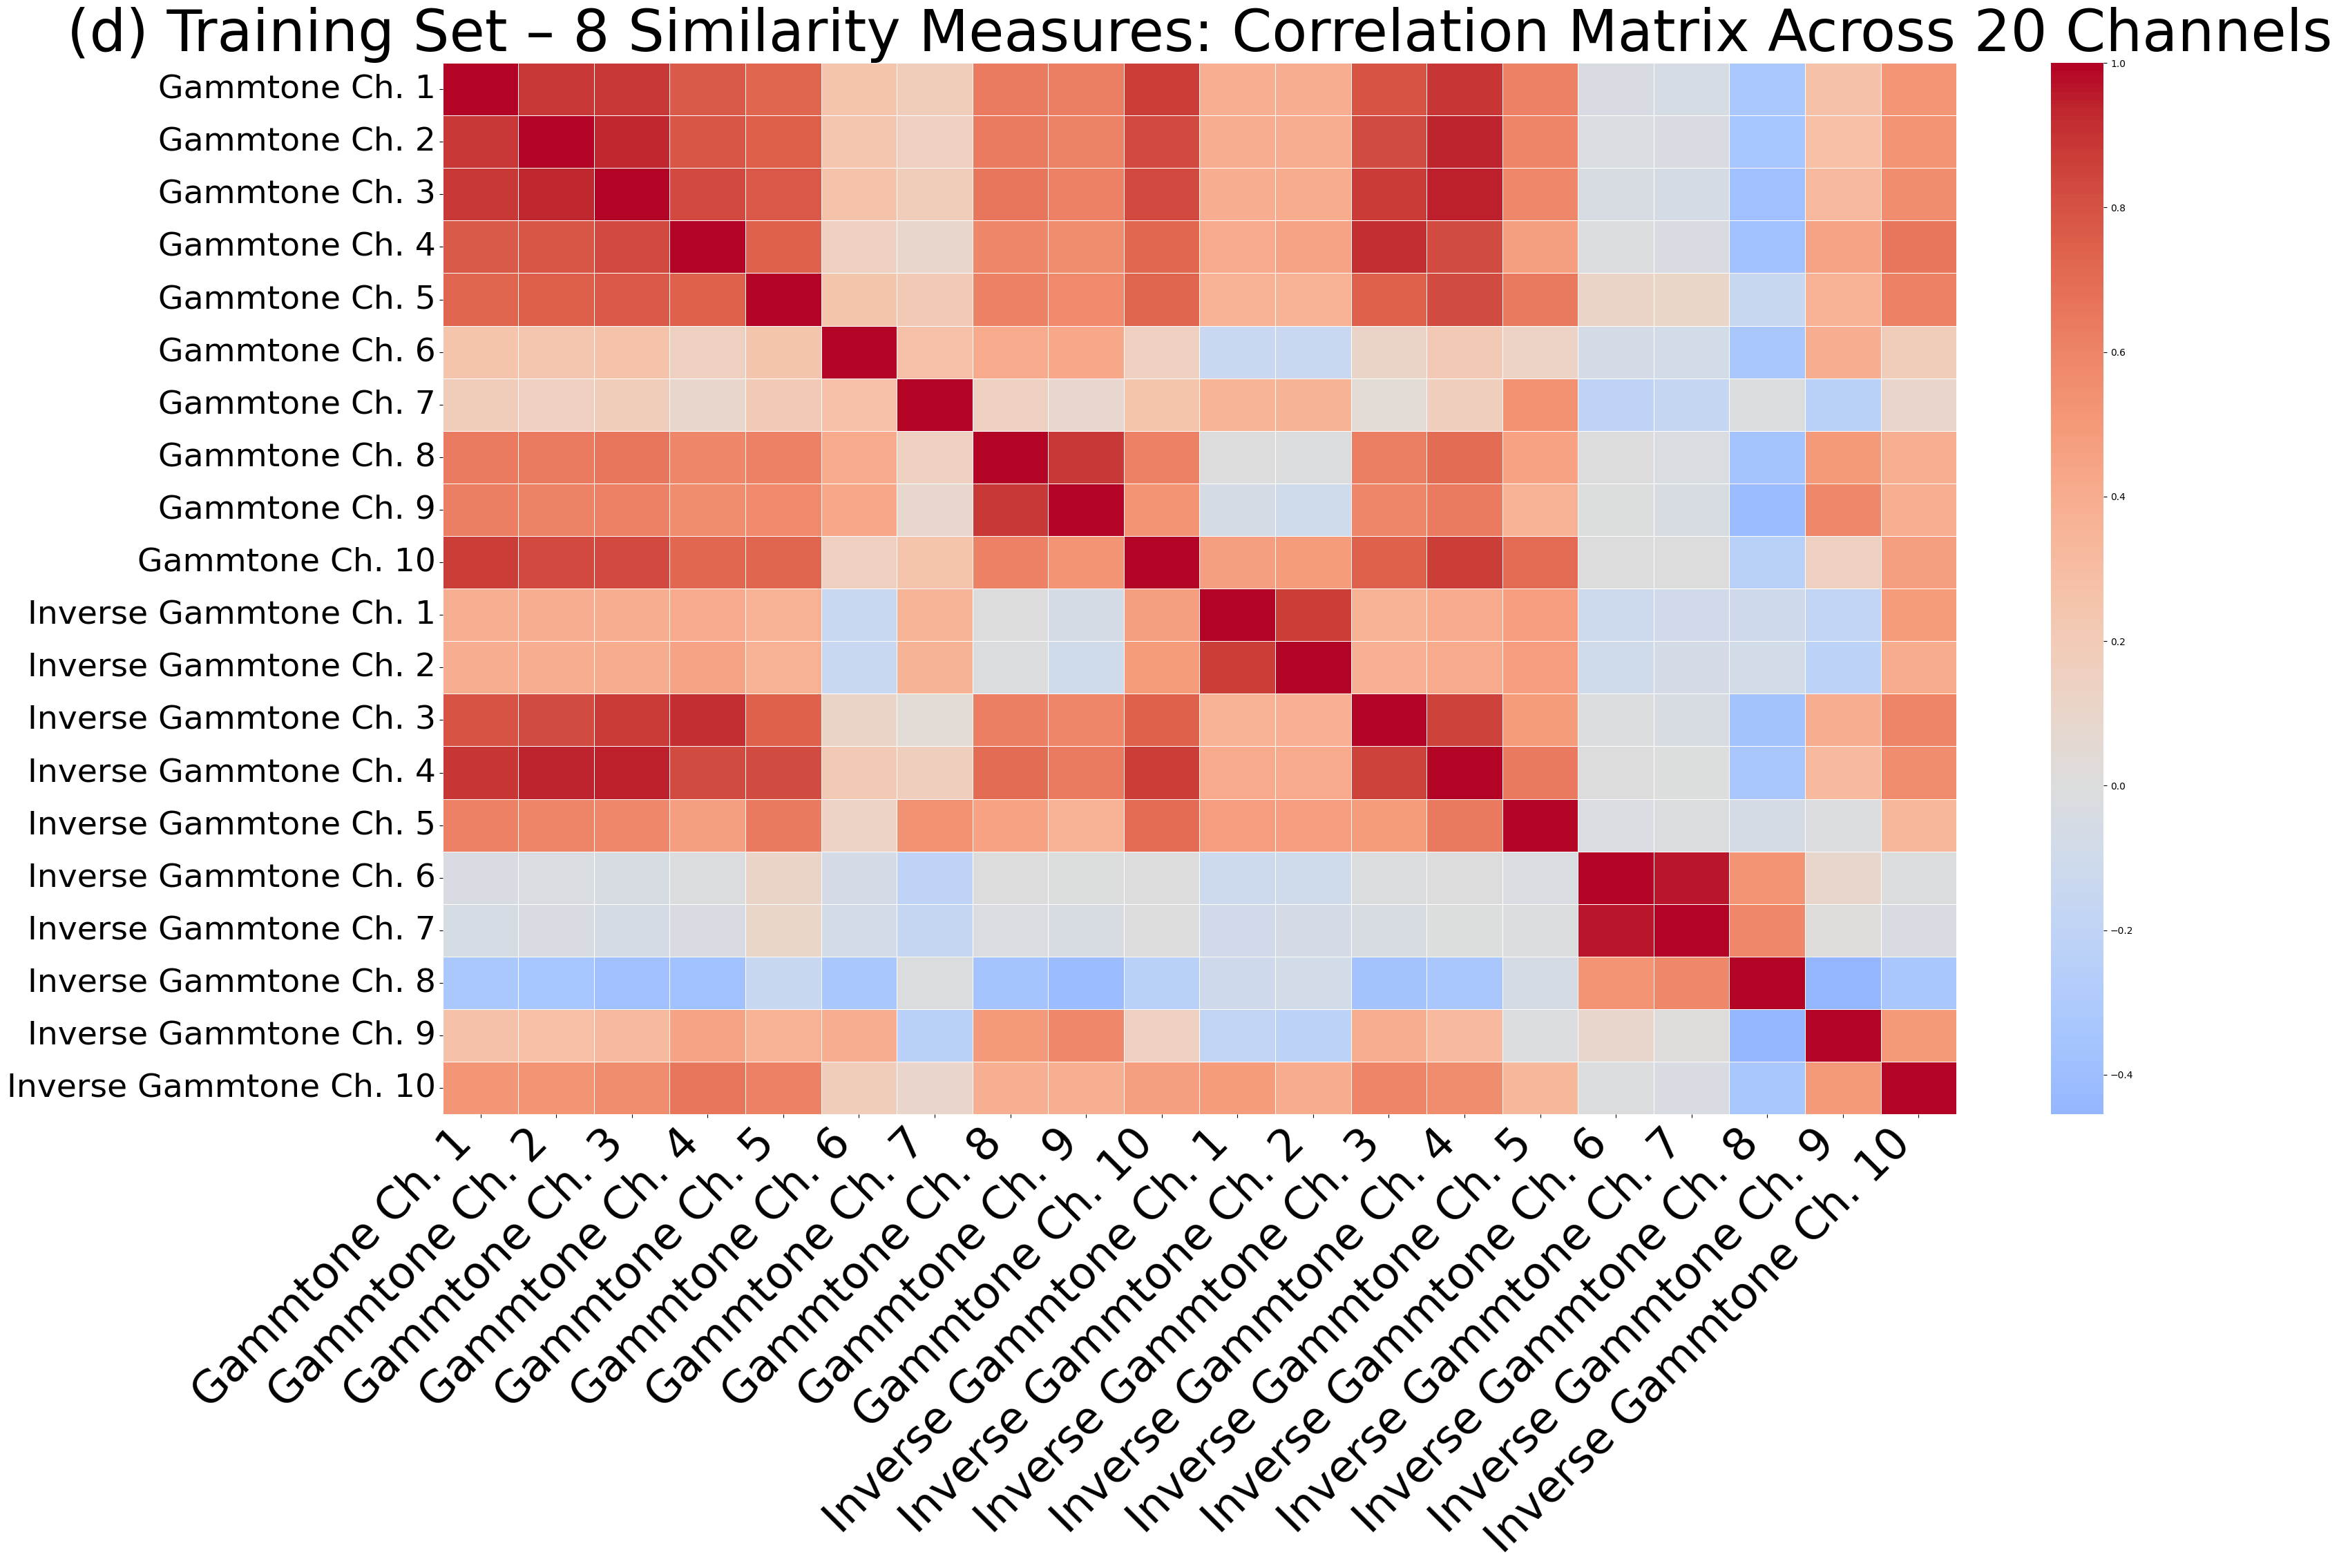

mean of means: 0.31506696638216497
std of means: 0.359757596558789


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 
# Ensure data is a Pandas DataFrame
train_dataset.data = pd.DataFrame(train_dataset.data)

# Ensure columns are sorted
train_dataset.data.columns = sorted_list

# Compute the correlation matrix
set_data = train_dataset

def compute_avg_over_metrices_type(set_data):
    num_cols = 10  # 10 gammatone + 10 inverse gammatone = 20 total
    num_channels = 20

    corr_matrices = []
    mean_matrices = []

    for i in range(0, 80, 10):  # Only first 80 columns are gammatone
        sub_data_gammatone = set_data.data.iloc[:, i:i+10]
        print("Gammatone features:", sorted_list[i:i+10])
        
        sub_data_gammatone_inv = set_data.data.iloc[:, 80+i:80+i+10]
        print("Inverse Gammatone features:", sorted_list[80+i:80+i+10])
        
        sub_data = pd.concat([sub_data_gammatone, sub_data_gammatone_inv], axis=1)
        
        corr_matrices.append(sub_data.corr())
        mean_matrices.append(np.mean(sub_data))

    # Convert the list to a 3D NumPy array
    corr_matrices = np.array(corr_matrices)
    #corr_matrices = np.mean(corr_matrices, axis=0)  # Average over the 8 similarity measures
    print("corr_matrices shape:", corr_matrices.shape)  # should be (8, 20, 20)

    # Compute statistics excluding the diagonal
    mask = ~np.eye(num_channels, dtype=bool)  # 20x20 identity matrix inverted
    # mean_scalars = np.array([m[mask].mean() for m in corr_matrices])
    # std_scalars = np.array([m[mask].std() for m in corr_matrices])

    mean_corr_matrices = np.mean(corr_matrices, axis=0)
    
    mean_titles = [f"Gammtone Ch. {idx+1}" for idx in range(10)]
    mean_titles2 = [f"Inverse Gammtone Ch. {idx+1}" for idx in range(10)]
    mean_titles = mean_titles + mean_titles2
    mean_corr_df = pd.DataFrame(mean_corr_matrices, index=mean_titles, columns=mean_titles)
    # Create a combined annotation matrix with mean and variance values
    #annotations = mean_corr_df.round(2).astype(str) + " (" + variance_corr_df.round(2).astype(str) + ")"

    plt.figure(figsize=(34, 24))
    sns.heatmap(mean_corr_df, fmt="", cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"color": "black","size": 22})#, annot=annotations)  # Set annotation text color to black)
    plt.title("(d) Training Set – 8 Similarity Measures: Correlation Matrix Across 20 Channels", fontsize=60)
    plt.xticks(rotation=45, ha='right', fontsize=46)
    plt.yticks(rotation=0, fontsize=34)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.show()
    
    #mean_of_means = np.mean(mean_scalars)
    #std_of_means = np.std(mean_scalars)
    mean_of_means = np.mean(mean_corr_matrices[mask])
    std_of_means = np.std(mean_corr_matrices[mask])
    print("mean of means:",mean_of_means)
    print("std of means:",std_of_means)
    

compute_avg_over_metrices_type(set_data)


In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
train_dataset.data = pd.DataFrame(train_dataset.data)
train_dataset.data.columns = sorted_list
set_data = train_dataset

def compute_avg_over_metrices_type(set_data):
    num_cols = 10
    num_rows = 10

    corr_matrices = []

    for i in range(0, set_data.data.shape[1], 10):
        sub_data = set_data.data.iloc[:, i:i+10]
        print(set_data.data.columns[i:i+10])
        corr_matrices.append(sub_data.corr())

    corr_matrices = np.array(corr_matrices)
    print("corr_matrices shape:", corr_matrices.shape)

    gammatone_corr_matrices = corr_matrices[:8]
    inv_gammatone_corr_matrices = corr_matrices[8:]

    results = {}

    mean_corrs = []

    for name, matrices in zip(["Gammatone", "Inverse Gammatone"], [gammatone_corr_matrices, inv_gammatone_corr_matrices]):
        mean_corr_matrix = np.mean(matrices, axis=0)
        mean_titles = [f"Ch. {idx+1}" for idx in range(10)]
        mean_corr_df = pd.DataFrame(mean_corr_matrix, index=mean_titles, columns=mean_titles)
        mean_corrs.append((name, mean_corr_df))

    return mean_corrs

def compute_over_channels(set_data):
    total_channels = 10
    matrices = []
    
    set1 = set_data.data
    set1 = set1[sorted_list]
    prefixes = ['filter-gammatone-channel-', 'filter-gammtone_inv-channel-']

    for prefix in prefixes:
        for channel in range(1, total_channels + 1):
            channel_prefix = f'{prefix}{channel}-'
            selected_features = [feat for feat in set1.columns if feat.startswith(channel_prefix)]
            if not selected_features:
                continue
            sub_matrix = set1[selected_features]
            matrices.append(sub_matrix.corr().to_numpy())

    matrices = np.array(matrices)
    mean_corr_matrix = np.mean(matrices, axis=0)

    type_similarity = [
        'Chi-square', 'Correlation', 'Hellinger', 'Intersection',
        'Jensen-Shannon', 'Kullback-Leibler Divergence',
        'Modified Kolmogorov-Smirnov', 'Symmetrised Kullback-Leibler'
    ]

    mean_titles = [f"{sim}" for sim in type_similarity]
    mean_corr_df = pd.DataFrame(mean_corr_matrix, index=mean_titles, columns=mean_titles)

    return mean_corr_df


In [35]:
# First, get the matrices
gammatone_result, inverse_gammatone_result = compute_avg_over_metrices_type(set_data)
similarity_result = compute_over_channels(set_data)

# Create the combined figure
fig = plt.figure(figsize=(70, 80))

# Top: two subplots
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))

# Bottom: one centered subplot
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)

# Plot (a) Gammatone
sns.heatmap(gammatone_result[1], ax=ax1, cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"color": "black", "size": 22})
ax1.set_title("(a) Training Set – 8 Similarity Measures: Gammatone Correlation Matrix Across 10 Channels", fontsize=60, pad=20)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=46)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=46)

# Plot (b) Inverse Gammatone
sns.heatmap(inverse_gammatone_result[1], ax=ax2, cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"color": "black", "size": 22})
ax2.set_title("(b) Training Set – 8 Similarity Measures: Inverse Gammatone Correlation Matrix Across 10 Channels", fontsize=60, pad=20)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=46)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=46)

# Plot (c) Similarity Measures
sns.heatmap(similarity_result, ax=ax3, cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"color": "black", "size": 22})
ax3.set_title("(c) Training Set – Correlation Matrix of the 8 Similarity Measures", fontsize=60, pad=20)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=46)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0, fontsize=46)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Index(['filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]'],
      dtype='object')
Index(['filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
       'filter-gammatone-channel-3-dis